In [17]:
from pathlib import Path
from copy import deepcopy
import importlib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Reload local analysis modules so rerunning this notebook in a long-lived
# kernel uses the current function signatures rather than cached imports.
import pmt.preprocessing as _pmt_preprocessing
import pmt.selection as _pmt_selection
import pmt.io as _pmt_io
import pmt.provenance as _pmt_provenance
importlib.reload(_pmt_preprocessing)
importlib.reload(_pmt_selection)
importlib.reload(_pmt_io)
importlib.reload(_pmt_provenance)

from pmt.io import *
from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
from pmt.provenance import *
from pmt.fit import *
from pmt.fit.core import *
from pmt.fit.poisson import fit_poisson_spe
from pmt.fit.bellamy import fit_bellamy_spe

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Single-voltage fit

Edit the next cell to choose one cached acquisition, charge estimator, fit range,
and model. Preprocessing and selection controls are deliberately absent: the
notebook reads their complete versioned manifest from the **pre-cut** cache written
by `Selection.ipynb`, then rebuilds exactly those selections.


In [18]:
# ======================== STANDALONE CONFIGURATION ========================
# Batch_analysis.ipynb supplies batch_* fit values automatically. When running
# directly, edit the values in the `else` block. Preprocessing and selection
# settings are loaded later from Selection.ipynb's cache manifest.
running_from_batch = all(
    name in globals() for name in ("batch_file_name", "batch_fit_inputs_dir")
)

if running_from_batch:
    file_name = batch_file_name
    fit_inputs_path = Path(batch_fit_inputs_dir)
    fit_output_root = Path(batch_fit_output_dir)
    save_plots = bool(globals().get("batch_save_plots", False))

    charge_method_names = list(globals().get("batch_charge_methods", ["full_waveform"]))
    fit_model_names = list(globals().get("batch_fit_models", ["poisson"]))
    maxPE = globals().get("batch_max_npe", 3)
    nbins = int(globals().get("batch_fit_bins", 250))
    fit_maxfev = int(globals().get("batch_fit_maxfev", 100000))
    fit_range_overrides = globals().get("batch_fit_range_overrides", {})
    fit_parameter_overrides = globals().get("batch_fit_parameter_overrides", {})

    plot_rejected_waveforms = bool(globals().get("batch_plot_rejected_waveforms", False))
    n_rejected_waveforms = int(globals().get("batch_rejected_waveform_sample", 40))
    rejected_waveform_seed = int(globals().get("batch_rejected_waveform_seed", 12345))
    n_example_waveforms = int(globals().get("batch_example_waveform_count", 10))
    example_high_snr_threshold = float(globals().get("batch_example_high_snr_threshold", 15.0))
    example_waveform_seed = int(globals().get("batch_example_waveform_seed", 12345))
else:
    # Choose the cache written by Selection.ipynb. Its manifest supplies the
    # raw-data path, channel, preprocessing, and selection configuration.
    analysis_dir = Path("plots/dark_counts")
    file_name = "WA0089_800V_Dark_20microV_trig"
    fit_inputs_path = analysis_dir / "fit_data"
    fit_output_root = analysis_dir / "fit"
    save_plots = False

    # Fit grid for this voltage.
    charge_method_names = ["fixed_pulse_window"]  # or full_waveform/led_window
    fit_model_names = ["poisson","bellamy"]            # add "bellamy" if desired
    maxPE = 6
    nbins = 250
    fit_maxfev = 100000

    # Optional fit ranges. Keys may be a method name or (method, selection).
    # Empty/None uses that sample's finite min/max.
    fit_range_overrides = {
        # "full_waveform": (-20.0, 120.0),
        # ("full_waveform", "dark_count_quality_above_snr15"): (-20.0, 100.0),
    }

    # Optional parameter-spec overrides, applied after the model defaults below.
    # Keys may be model, (model, method), or (model, method, selection).
    # Each spec is [initial, lower bound, upper bound, fixed].
    fit_parameter_overrides = {
        # ("poisson", "full_waveform", "dark_count_quality_above_snr15"): {
        #     "q1_mV_ns": [30.0, 10.0, 80.0, False],
        # },
    }

    # Waveform diagnostics (raw data are read only for the sampled events).
    plot_rejected_waveforms = True
    n_rejected_waveforms = 3
    rejected_waveform_seed = 12345
    n_example_waveforms = 3
    example_high_snr_threshold = 15.0
    example_waveform_seed = 12345

if not isinstance(maxPE, int) or isinstance(maxPE, bool) or maxPE < 0:
    raise ValueError("maxPE must be a non-negative integer")
if nbins < 1 or fit_maxfev < 1:
    raise ValueError("nbins and fit_maxfev must be positive integers")

voltage_match = re.search(r"(?:^|_)(\d+(?:\.\d+)?)V(?:_|$)", file_name)
if voltage_match is None:
    raise ValueError(f"Could not determine PMT voltage from file name: {file_name}")
voltage_V = float(voltage_match.group(1))

save_dir = str(fit_output_root / f"{voltage_V:g}V")
file_nickname = file_name
savefit_path = fit_output_root / "fit_results"
savefit_path.mkdir(parents=True, exist_ok=True)

print(f"Acquisition: {file_name}")
print(f"Cached dataframe: {(fit_inputs_path / (file_name + '_df.pkl')).resolve()}")
print(f"Charge method(s) / model(s): {charge_method_names} / {fit_model_names}")


Acquisition: WA0089_800V_Dark_20microV_trig
Cached dataframe: /home/aviv/projects/TAU_Neutrino_Lab/PMT-characterization/PMT_calibration/plots/dark_counts/fit_data/WA0089_800V_Dark_20microV_trig_df.pkl
Charge method(s) / model(s): ['fixed_pulse_window'] / ['poisson', 'bellamy']


In [19]:
df_file = fit_inputs_path / f"{file_nickname}_df.pkl"
if not df_file.exists():
    raise FileNotFoundError(
        f"Missing cached dataframe {df_file}. Run Selection.ipynb for this "
        "voltage first; Fit.ipynb never creates preprocessing caches."
    )
print(f"Loading cached pre-cut dataframe from {df_file}")
df = pd.read_pickle(df_file)
cache_provenance = load_selection_cache_provenance(
    df, expected_acquisition=file_name
)
preprocessing_settings = cache_provenance["preprocessing"]
selection_settings = cache_provenance["selection"]

# Selection.ipynb is the sole authority for every setting that shaped the
# dataframe or determines which events enter the fit.
channel = preprocessing_settings["channel"]
baseline_window_ns = tuple(preprocessing_settings["baseline_window_ns"])
led_time_ns = float(preprocessing_settings["led_time_ns"])
pre_led_ns = float(preprocessing_settings["pre_led_ns"])
post_led_ns = float(preprocessing_settings["post_led_ns"])
peak_snr_threshold = preprocessing_settings["peak_snr_threshold"]
peak_prominence_snr = preprocessing_settings["peak_prominence_snr"]
peak_distance_samples = preprocessing_settings["peak_distance_samples"]
peak_width_samples = preprocessing_settings["peak_width_samples"]
if peak_width_samples is not None:
    peak_width_samples = tuple(peak_width_samples)
require_clean_baseline = bool(preprocessing_settings["require_clean_baseline"])
baseline_clean_snr = float(preprocessing_settings["baseline_clean_snr"])
skip_corrupt_files = bool(preprocessing_settings["skip_corrupt_files"])
fixed_pulse_window_charge = preprocessing_settings["fixed_pulse_window_charge"]
if not isinstance(fixed_pulse_window_charge, dict):
    raise ValueError("Invalid fixed_pulse_window_charge cache manifest")

cut_thresholds_snr = list(selection_settings["cut_thresholds_snr"])
selection_mode = selection_settings["selection_mode"]
timing_reference_snr = float(selection_settings["timing_reference_snr"])
peak_timing_tolerance_ns = float(selection_settings["peak_timing_tolerance_ns"])
timing_reference_requires_single_peak = bool(
    selection_settings["timing_reference_requires_single_peak"]
)
max_allowed_peaks = int(selection_settings["max_allowed_peaks"])
include_no_peak_cuts = bool(selection_settings["include_no_peak_cuts"])
include_shape_cut = bool(selection_settings["include_shape_cut"])
min_shape_reference_pulses = int(selection_settings["min_shape_reference_pulses"])
shape_quantiles = tuple(selection_settings["shape_quantiles"])
selection_names = selection_settings["selection_names"]
if selection_names is not None:
    selection_names = list(selection_names)
generated_selection_names = tuple(selection_settings["generated_selection_names"])

required_columns = {
    "area_mV_ns", "charge_led_window_mV_ns", "snr", "n_peaks",
    "peak_time_ns", "event_file", "event_segment",
}
if include_shape_cut:
    required_columns.update({
        "peak_width_ns", "rise_time_10_90_ns", "fall_time_90_10_ns"
    })
if fixed_pulse_window_charge.get("enabled", False):
    required_columns.add(fixed_pulse_window_charge["column"])
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(
        f"Cached dataframe is missing {sorted(missing_columns)}. "
        "Rerun Selection.ipynb with the current analysis code."
    )

data_dir = Path(cache_provenance["data_dir"])
files = [Path(value) for value in cache_provenance["source_files"]]
source_path_by_name = {path.name: path for path in files}
if len(source_path_by_name) != len(files):
    raise ValueError("Selection manifest contains duplicate HDF5 basenames.")
expected_source_names = set(source_path_by_name)
cached_source_names = {
    Path(value).name for value in df["event_file"].dropna().unique()
}
unexpected_sources = cached_source_names.difference(expected_source_names)
if unexpected_sources:
    raise ValueError(
        f"Cache {df_file} contains HDF5 files absent from its Selection "
        f"manifest: {sorted(unexpected_sources)}. Rerun Selection.ipynb."
    )
missing_cached_sources = expected_source_names.difference(cached_source_names)
if missing_cached_sources:
    print(
        "Warning: the cache contains no retained events from these source "
        f"segments: {sorted(missing_cached_sources)}. They may have been empty, "
        "corrupt, or fully rejected."
    )

needs_raw_waveforms = (n_example_waveforms > 0) or (
    plot_rejected_waveforms and n_rejected_waveforms > 0
)
missing_raw_sources = sorted(
    name for name in cached_source_names if not source_path_by_name[name].is_file()
)
if needs_raw_waveforms and missing_raw_sources:
    raise FileNotFoundError(
        "Raw waveform diagnostics are enabled, but source files recorded by "
        f"Selection.ipynb are missing: {missing_raw_sources}. Rerun Selection.ipynb "
        "after moving data, or disable the waveform diagnostics."
    )
# Point sampled-event diagnostics at the exact source paths in the manifest.
df["event_file"] = df["event_file"].map(
    lambda value: str(source_path_by_name[Path(value).name])
)

baseline_reference_value = preprocessing_settings["baseline_reference_path"]
baseline_reference_path = (
    None if baseline_reference_value is None else Path(baseline_reference_value)
)
baseline_reference_time_ns = None
baseline_reference_mV = None
if baseline_reference_path is not None:
    if needs_raw_waveforms and not baseline_reference_path.is_file():
        raise FileNotFoundError(
            "Raw waveform diagnostics need the baseline reference recorded by "
            f"Selection.ipynb, but it is missing: {baseline_reference_path}"
        )
    if baseline_reference_path.is_file():
        reference_data = load_baseline_reference(baseline_reference_path)
        baseline_reference_time_ns = reference_data["time_ns"]
        baseline_reference_mV = reference_data["baseline_template_mV"]

if baseline_reference_path is not None and "baseline_reference_residual_mean_mV" not in df.columns:
    raise ValueError(
        "Cached data were created without median-reference baseline subtraction. "
        "Rerun Selection.ipynb."
    )

print(f"Loaded {len(df):,} pre-cut events from {len(cached_source_names)} HDF5 segments.")
print(f"Raw data recorded by Selection: {data_dir}")
print(f"Selection(s): {selection_names or 'all generated selections'}")
print("Preprocessing settings loaded from Selection manifest:")
for key, value in preprocessing_settings.items():
    print(f"  {key}: {value}")
print("Selection settings loaded from Selection manifest:")
for key, value in selection_settings.items():
    print(f"  {key}: {value}")


Loading cached pre-cut dataframe from plots/dark_counts/fit_data/WA0089_800V_Dark_20microV_trig_df.pkl
Loaded 269,908 pre-cut events from 9 HDF5 segments.
Raw data recorded by Selection: /home/aviv/projects/TAU_Neutrino_Lab/PMT-characterization/PMT_calibration/PMT_Data/Dark_Counts/trig20microV
Selection(s): all generated selections
Preprocessing settings loaded from Selection manifest:
  channel: Channel 3
  baseline_window_ns: (0.0, 20.0)
  led_time_ns: 36.0
  pre_led_ns: 20.0
  post_led_ns: 80.0
  peak_snr_threshold: 8.0
  peak_prominence_snr: 6.0
  peak_distance_samples: 1024
  peak_width_samples: (257, 640)
  require_clean_baseline: True
  baseline_clean_snr: 8.0
  baseline_reference_path: None
  skip_corrupt_files: True
  fixed_pulse_window_charge: {'enabled': True, 'column': 'charge_fixed_pulse_window_mV_ns', 'reference_snr': 15.0, 'width_quantile': 0.95, 'min_reference_pulses': 100, 'read_chunk_size': 512, 'reference_pulses': 7350, 'center_ns': 49.2305368906207, 'width_ns': 31.2

Selection mode: dark_counts
Dark-count mode: LED timing estimation and timing cuts are disabled.

--- No peak cuts ---
Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                      269908      100.0%        100.0%

--- Single peak (timing ignored) at SNR >= 15 ---
Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                      269908      100.0%        100.0%
SNR >= 15: single peak       269819      100.0%        100.0%

--- Single peak (timing ignored) at SNR >= 20 ---
Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                      269908      100.0%        100.0%
SNR >= 20: single peak       269837      100.0%        100.0%

--- Single peak (timing ignored) at SNR >= 30 ---
Cut                            Kept    Rela

[]

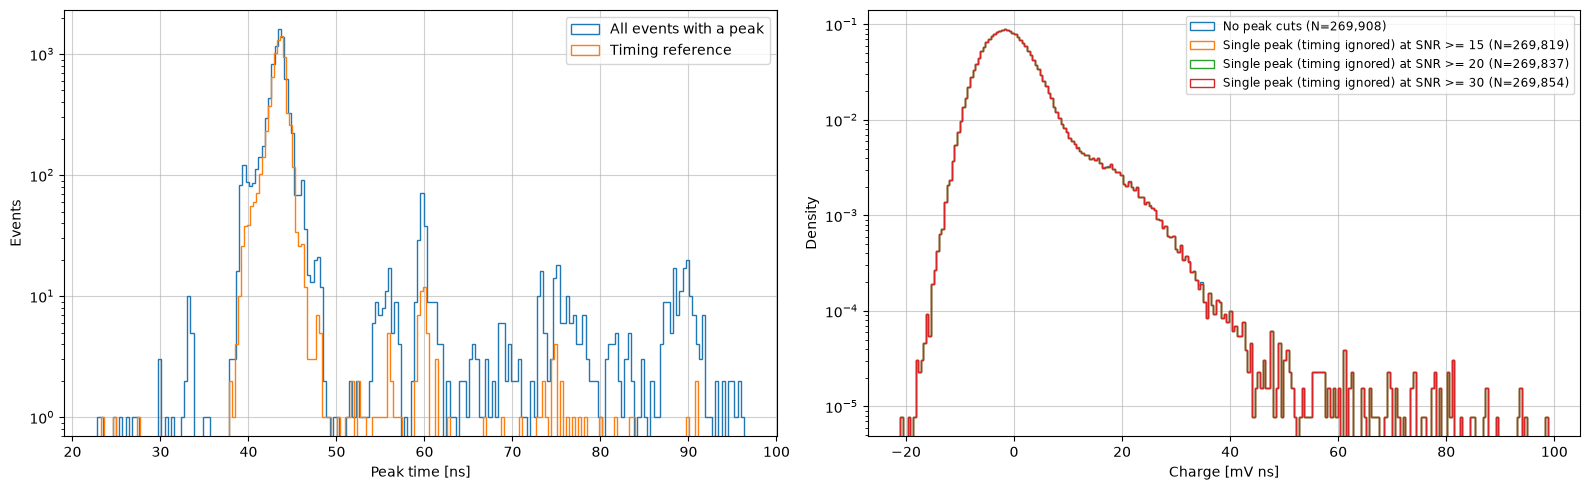

In [20]:
selection_analysis = build_calibration_selections(
    df,
    cut_thresholds_snr=cut_thresholds_snr,
    selection_mode=selection_mode,
    timing_reference_snr=timing_reference_snr,
    peak_timing_tolerance_ns=peak_timing_tolerance_ns,
    timing_reference_requires_single_peak=timing_reference_requires_single_peak,
    max_allowed_peaks=max_allowed_peaks,
    include_no_peak_cuts=include_no_peak_cuts,
    include_shape_cut=include_shape_cut,
    min_shape_reference_pulses=min_shape_reference_pulses,
    shape_quantiles=shape_quantiles,
    selection_names=selection_names,
)

selection_mode = selection_analysis["selection_mode"]
selection_configs = selection_analysis["selection_configs"]
selected_dfs = selection_analysis["selected_dfs"]
selection_rejected_masks = selection_analysis["rejected_masks"]
selection_cutflows = selection_analysis["cutflows"]
uses_led_timing = selection_analysis["uses_led_timing"]
timing_reference = selection_analysis["timing_reference"]
expected_peak_time_ns = selection_analysis["expected_peak_time_ns"]
allowed_peak_window_ns = selection_analysis["allowed_peak_window_ns"]
shape_cut_available = selection_analysis["shape_cut_available"]
shape_cut_ranges = selection_analysis["shape_cut_ranges"]

rebuilt_selection_names = tuple(config["name"] for config in selection_configs)
if rebuilt_selection_names != generated_selection_names:
    raise ValueError(
        "Selections rebuilt by Fit.ipynb differ from the names recorded by "
        f"Selection.ipynb: cache={generated_selection_names}, "
        f"rebuilt={rebuilt_selection_names}. Rerun Selection.ipynb."
    )

print(f"Selection mode: {selection_mode}")
if uses_led_timing:
    print(f"Expected LED peak time: {expected_peak_time_ns:.2f} ns")
    print(f"Allowed peak window: {allowed_peak_window_ns} ns")
else:
    print("Dark-count mode: LED timing estimation and timing cuts are disabled.")
if include_shape_cut and not shape_cut_available:
    print(
        f"Pulse-shape cut requested but skipped: fewer than "
        f"{min_shape_reference_pulses} reference pulses."
    )
for column, limits in shape_cut_ranges.items():
    print(f"{column}: {limits[0]:.3g} to {limits[1]:.3g} ns")

for config in selection_configs:
    print(f"\n--- {config['label']} ---")
    selection_cutflows[config["name"]].print()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
finite_peak_times = df.loc[np.isfinite(df["peak_time_ns"]), "peak_time_ns"]
if not finite_peak_times.empty:
    axes[0].hist(finite_peak_times, bins=200, histtype="step", label="All events with a peak")
if not timing_reference.empty:
    axes[0].hist(timing_reference, bins=200, histtype="step", label="Timing reference")
if uses_led_timing:
    axes[0].axvline(expected_peak_time_ns, color="tab:red", label="Expected LED peak")
    axes[0].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.2, label="Accepted window")
axes[0].set(xlabel="Peak time [ns]", ylabel="Events", yscale="log")
axes[0].legend()

for config in selection_configs:
    values = selected_dfs[config["name"]]["area_mV_ns"]
    axes[1].hist(
        values, bins=nbins, density=True, histtype="step",
        label=f"{config['label']} (N={len(values):,})",
    )
axes[1].set(xlabel="Charge [mV ns]", ylabel="Density", yscale="log")
axes[1].legend(fontsize="small")
fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname, "selection_comparison", Nevents=None)


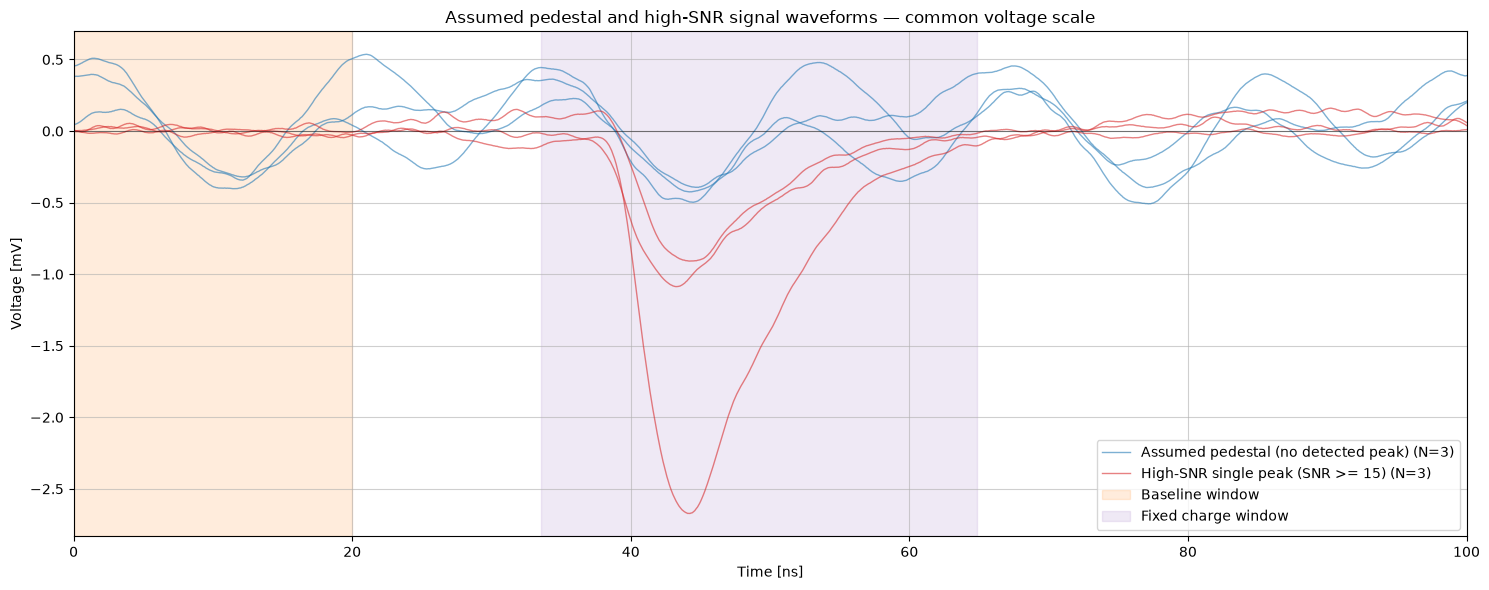

In [21]:
# Show full-record examples of the two populations underlying calibration.
# n_peaks == 0 is treated as pedestal; signal examples must have exactly one
# detected peak, matching the later quality cut, and exceed the configurable SNR.
example_rng = np.random.default_rng(example_waveform_seed)

example_populations = [
    (
        "pedestal_no_detected_peak",
        df["n_peaks"].eq(0),
        "Assumed pedestal (no detected peak)",
        "tab:blue",
    ),
    (
        "single_peak_high_snr",
        df["n_peaks"].eq(1) & df["snr"].ge(example_high_snr_threshold),
        f"High-SNR single peak (SNR >= {example_high_snr_threshold:g})",
        "tab:red",
    ),
]

fig, ax = plt.subplots(figsize=(15, 6))
plotted_population_count = 0
time_limits = None

for population_name, population_mask, population_label, population_color in example_populations:
    population_df = df.loc[population_mask]
    sample_size = min(n_example_waveforms, len(population_df))
    if sample_size == 0:
        print(f"No events available for waveform diagnostic: {population_label}")
        continue
    sample_indices = example_rng.choice(
        population_df.index.to_numpy(), size=sample_size, replace=False
    )
    example_df = population_df.loc[sample_indices].sort_index()
    example_time_ns, example_waveforms = load_event_waveforms(
        example_df,
        channel=channel,
        baseline_window_ns=baseline_window_ns,
        baseline_reference_time_ns=baseline_reference_time_ns,
        baseline_reference_mV=baseline_reference_mV,
    )

    time_limits = (example_time_ns[0], example_time_ns[-1])
    for waveform_index, waveform in enumerate(example_waveforms):
        ax.plot(
            example_time_ns, waveform, color=population_color,
            linewidth=1.0, alpha=0.58,
            label=(f"{population_label} (N={sample_size})" if waveform_index == 0 else None),
        )
    plotted_population_count += 1

if plotted_population_count:
    ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.14, label="Baseline window")
    if fixed_pulse_window_charge.get("enabled", False):
        ax.axvspan(*fixed_pulse_window_charge["window_ns"], color="tab:purple", alpha=0.14, label="Fixed charge window")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.45)
    ax.set(
        xlabel="Time [ns]", ylabel="Voltage [mV]",
        title="Assumed pedestal and high-SNR signal waveforms — common voltage scale",
        xlim=time_limits,
    )
    ax.legend()
    fig.tight_layout()
    save_plot(
        fig, save_plots, save_dir, file_nickname,
        "example_waveforms_pedestal_vs_high_snr", Nevents=None,
    )
else:
    plt.close(fig)


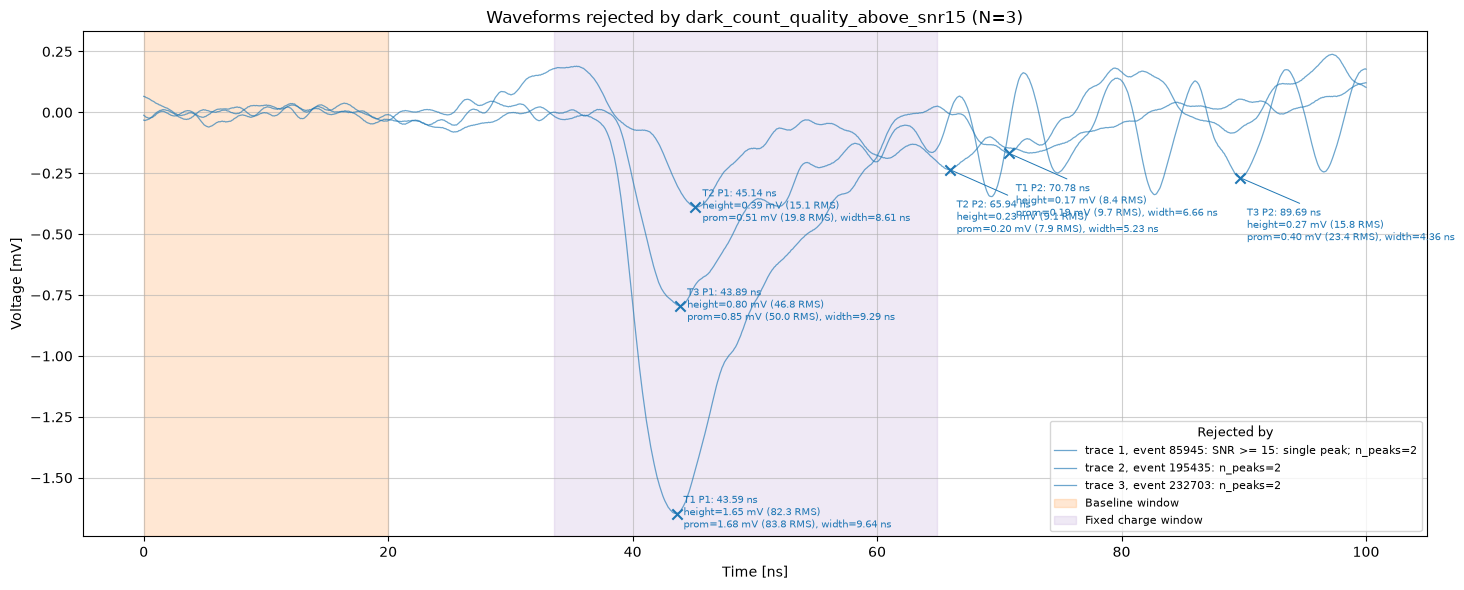

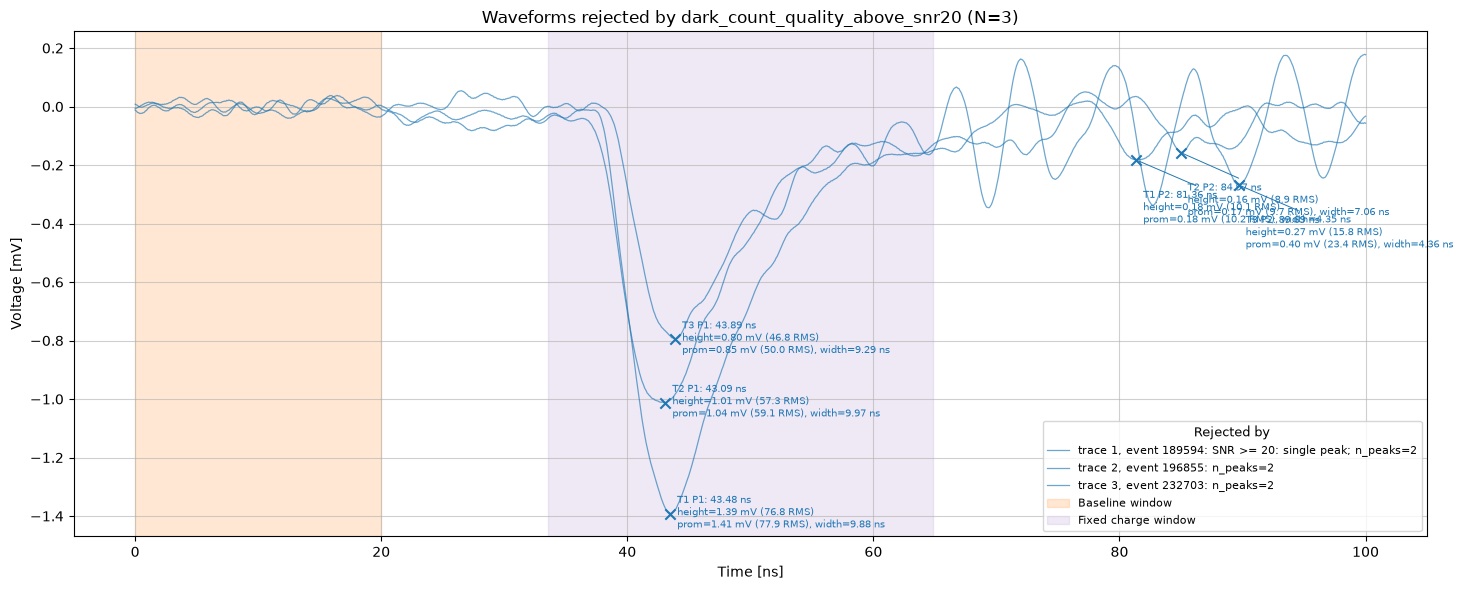

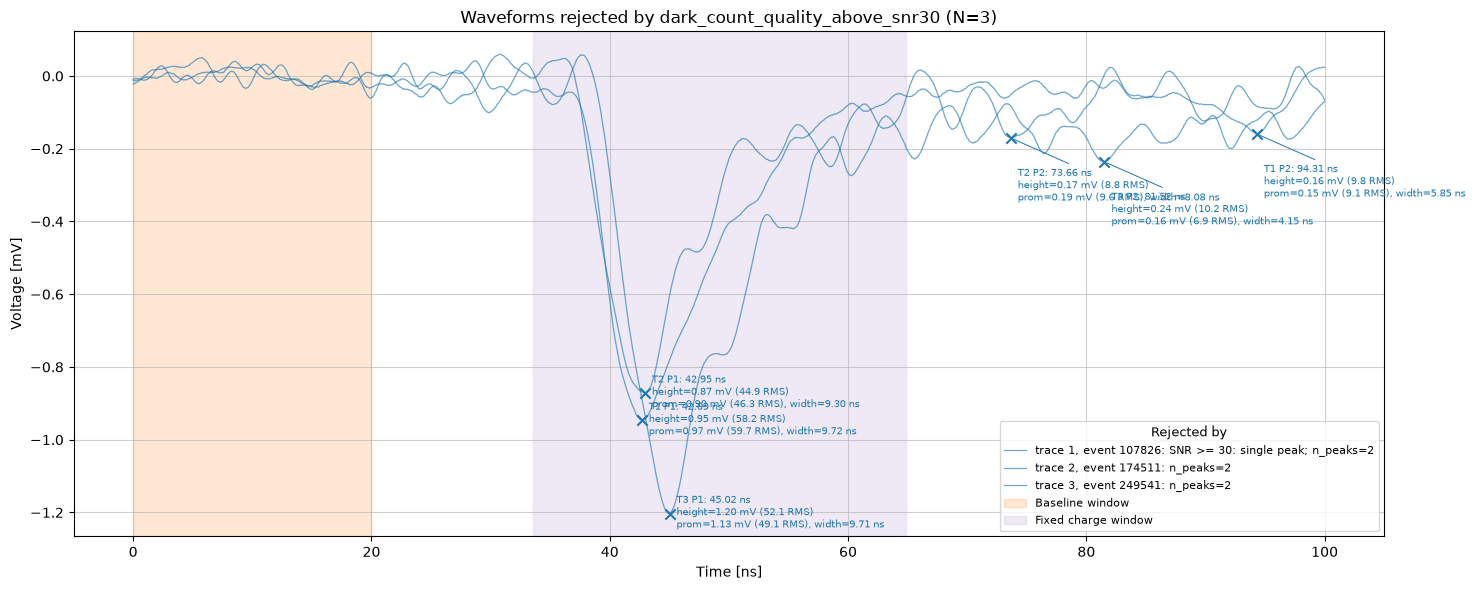

In [22]:
# Optional diagnostic: reload a small sample of rejected waveforms for each
# active selection. This uses cached event_file/event_segment bookkeeping and
# reads only the requested events, not the full HDF5 dataset.

if plot_rejected_waveforms:
    rng = np.random.default_rng(rejected_waveform_seed)
    for config in selection_configs:
        name = config["name"]
        if name == "no_peak_cuts":
            continue
        # Record every failed cut independently; one event may have several reasons.
        failed_cuts_by_event = {index: [] for index in df.index}
        for cut_name, keep_mask in config["cuts"]:
            keep_by_index = pd.Series(np.asarray(keep_mask, dtype=bool), index=df.index)
            for index in keep_by_index.index[~keep_by_index]:
                failed_cuts_by_event[index].append(cut_name)
        rejected_indices = [
            index for index, reasons in failed_cuts_by_event.items() if reasons
        ]
        rejected_df = df.loc[rejected_indices].copy()
        rejected_df["failed_cuts"] = [
            "; ".join(failed_cuts_by_event[index]) for index in rejected_indices
        ]
        if rejected_df.empty:
            print(f"No rejected events for {name}")
            continue

        sample_size = min(n_rejected_waveforms, len(rejected_df))
        sample_indices = rng.choice(rejected_df.index.to_numpy(), size=sample_size, replace=False)
        rejected_sample = rejected_df.loc[sample_indices].sort_index()
        rejected_time_ns, rejected_waveforms = load_event_waveforms(
            rejected_sample,
            channel=channel,
            baseline_window_ns=baseline_window_ns,
            baseline_reference_time_ns=globals().get("baseline_reference_time_ns", None),
            baseline_reference_mV=globals().get("baseline_reference_mV", None),
        )

        # Rerun the same detector so the diagnostic can show every peak that
        # contributed to cached n_peaks. The cache must have been regenerated
        # after changing these settings for the two counts to agree.
        _, detected_peaks, detected_properties = _pmt_preprocessing._find_waveform_peaks(
            rejected_waveforms,
            rejected_sample["baseline_rms_mV"].to_numpy(),
            polarity="negative",
            peak_snr_threshold=peak_snr_threshold,
            peak_prominence_snr=peak_prominence_snr,
            peak_distance_samples=peak_distance_samples,
            peak_width_samples=peak_width_samples,
        )

        # Overlay all sampled waveforms. Color identifies the failed cut(s);
        # each x marker and annotation identifies one detector-accepted peak.
        rejection_reasons = rejected_sample["failed_cuts"].unique().tolist()
        color_map = plt.get_cmap("tab10")
        reason_colors = {
            reason: color_map(i % color_map.N)
            for i, reason in enumerate(rejection_reasons)
        }
        reasons_already_labeled = set()
        fig, ax = plt.subplots(figsize=(15, 6))
        for trace_number, ((event_index, event), waveform, peaks, properties) in enumerate(zip(
            rejected_sample.iterrows(), rejected_waveforms, detected_peaks, detected_properties
        ), start=1):
            reason = event["failed_cuts"]
            detected_count = len(peaks)
            cached_count = int(event["n_peaks"])
            count_text = f"n_peaks={cached_count}"
            if detected_count != cached_count:
                count_text += f" (current settings: {detected_count})"
            label = (
                f"trace {trace_number}, event {event_index}: {reason}; {count_text}"
                if reason not in reasons_already_labeled
                else f"trace {trace_number}, event {event_index}: {count_text}"
            )
            ax.plot(
                rejected_time_ns, waveform, color=reason_colors[reason],
                linewidth=0.9, alpha=0.65, label=label,
            )
            baseline_rms = float(event["baseline_rms_mV"])
            peak_heights = properties.get("peak_heights", np.full(detected_count, np.nan))
            prominences = properties.get("prominences", np.full(detected_count, np.nan))
            widths = properties.get("widths", np.full(detected_count, np.nan))
            dt_ns = float(np.mean(np.diff(rejected_time_ns)))
            for peak_number, (peak, height, prominence, width) in enumerate(
                zip(peaks, peak_heights, prominences, widths), start=1
            ):
                peak_time = rejected_time_ns[peak]
                peak_voltage = waveform[peak]
                ax.scatter(peak_time, peak_voltage, marker="x", s=55, linewidths=1.5,
                           color=reason_colors[reason], zorder=5)
                ax.annotate(
                    (f"T{trace_number} P{peak_number}: {peak_time:.2f} ns\n"
                     f"height={height:.2f} mV ({height / baseline_rms:.1f} RMS)\n"
                     f"prom={prominence:.2f} mV ({prominence / baseline_rms:.1f} RMS), "
                     f"width={width * dt_ns:.2f} ns"),
                    xy=(peak_time, peak_voltage), xytext=(5, -10 - 35 * (peak_number - 1)),
                    textcoords="offset points", fontsize=7, color=reason_colors[reason],
                    arrowprops={"arrowstyle": "-", "color": reason_colors[reason], "lw": 0.7},
                )
            reasons_already_labeled.add(reason)
        ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.18, label="Baseline window")
        if fixed_pulse_window_charge.get("enabled", False):
            ax.axvspan(*fixed_pulse_window_charge["window_ns"], color="tab:purple", alpha=0.14, label="Fixed charge window")
        if uses_led_timing:
            ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.14, label="Accepted peak-time window")
        ax.set(
            xlabel="Time [ns]", ylabel="Voltage [mV]",
            title=f"Waveforms rejected by {name} (N={sample_size})",
        )
        ax.legend(title="Rejected by", fontsize=8, title_fontsize=9)
        fig.tight_layout()
        save_plot(
            fig, save_plots, save_dir, file_nickname,
            f"rejected_waveforms_{name}", Nevents=None,
        )
else:
    print("Rejected-waveform diagnostic disabled")


# Fit one step

In [23]:
# Choose charge samples and fit ranges

all_charge_methods = {
    "full_waveform": {"column": "area_mV_ns", "label": "Full waveform"},
    "led_window": {
        "column": "charge_led_window_mV_ns",
        "label": f"LED window [-{pre_led_ns:g}, +{post_led_ns:g}] ns",
    },
}
if fixed_pulse_window_charge.get("enabled", False):
    fixed_start_ns, fixed_stop_ns = fixed_pulse_window_charge["window_ns"]
    all_charge_methods["fixed_pulse_window"] = {
        "column": fixed_pulse_window_charge["column"],
        "label": (
            f"Fixed pulse window [{fixed_start_ns:.2f}, {fixed_stop_ns:.2f}] ns "
            f"({100 * fixed_pulse_window_charge['width_quantile']:.0f}th-percentile width)"
        ),
    }
elif "fixed_pulse_window" in charge_method_names:
    raise ValueError(
        "fixed_pulse_window was requested, but it was not enabled when this "
        "cache was built. Enable it in Selection.ipynb and rerun Selection."
    )
unknown_charge_methods = set(charge_method_names).difference(all_charge_methods)
if unknown_charge_methods:
    raise ValueError(f"Unknown charge methods: {sorted(unknown_charge_methods)}")
charge_methods = {name: all_charge_methods[name] for name in charge_method_names}
if not charge_methods:
    raise ValueError("No charge methods are enabled.")

fit_models = {model.lower() for model in fit_model_names}
unknown_fit_models = fit_models.difference({"poisson", "bellamy"})
if unknown_fit_models:
    raise ValueError(f"Unknown fit models: {sorted(unknown_fit_models)}")
if not fit_models:
    raise ValueError("No fit models are enabled.")

def requested_fit_range(method, selection_name, values):
    override = fit_range_overrides.get(
        (method, selection_name), fit_range_overrides.get(method)
    )
    if override is None:
        return (float(values.min()), float(values.max()))
    if len(override) != 2 or not np.all(np.isfinite(override)) or override[0] >= override[1]:
        raise ValueError(
            f"Invalid fit range for {method}/{selection_name}: {override!r}"
        )
    return tuple(float(value) for value in override)

fit_samples = {}
fit_ranges = {}
for method, method_config in charge_methods.items():
    charge_column = method_config["column"]
    fit_samples[method] = {}
    fit_ranges[method] = {}
    print(f"\n--- {method_config['label']} ({charge_column}) ---")
    for config in selection_configs:
        name = config["name"]
        values = selected_dfs[name][charge_column].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            raise ValueError(f"No finite {charge_column} values for selection {name}")
        fit_samples[method][name] = values
        fit_ranges[method][name] = requested_fit_range(method, name, values)
        print(
            f"{config['label']}: {len(values):,} events; "
            f"fit range={fit_ranges[method][name]}"
        )

print(f"Enabled fit models: {sorted(fit_models)}")



--- Fixed pulse window [33.59, 64.87] ns (95th-percentile width) (charge_fixed_pulse_window_mV_ns) ---
No peak cuts: 269,908 events; fit range=(-7.686450351629615, 91.1572279201448)
Single peak (timing ignored) at SNR >= 15: 269,819 events; fit range=(-7.686450351629615, 91.1572279201448)
Single peak (timing ignored) at SNR >= 20: 269,837 events; fit range=(-7.686450351629615, 91.1572279201448)
Single peak (timing ignored) at SNR >= 30: 269,854 events; fit range=(-7.686450351629615, 91.1572279201448)
Enabled fit models: ['bellamy', 'poisson']


# Fit configuration

Each parameter specification below is `[initial value, lower bound, upper bound,
is_fixed]`. Edit the defaults directly, or use `fit_parameter_overrides` in the
top configuration cell for a particular model/method/selection. You can rerun
the fit cells repeatedly without reloading raw waveforms.


Fit-range precedence is `(charge method, selection name)` then `charge method`,
then the finite data range. Parameter override precedence is model, then
`(model, method)`, then `(model, method, selection)`.


In [24]:
def parameter_specs_for(model, method, selection_name, defaults, n_events):
    specs = deepcopy(defaults)
    specs["n_total"] = [n_events, 0.5 * n_events, 1.5 * n_events, False]
    for key in (
        model,
        (model, method),
        (model, method, selection_name),
    ):
        overrides = fit_parameter_overrides.get(key, {})
        unknown = set(overrides).difference(specs)
        if unknown:
            raise ValueError(f"Unknown {model} parameter overrides: {sorted(unknown)}")
        specs.update(deepcopy(overrides))
    return specs


## Poisson

In [25]:
# Poisson SPE defaults. Edit initial values, bounds, or fixed flags here.
p0_poisson = {
    "q0_mV_ns": [1, -6.0, 10.0, False],
    "sigma0_mV_ns": [2, 1e-4, 50.0, False],
    "q1_mV_ns": [10, 0.5, 200.0, False],
    "sigma1_mV_ns": [4, 0.2, 100.0, False],
    "mu_pe": [0.06, 0.001, 5.0, False],
}



===== Poisson: Fixed pulse window [33.59, 64.87] ns (95th-percentile width) - No peak cuts =====
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         269908.0000 269160.6871     518.8306   [134954.0, 404862.0]   False
mu_pe                0.0600      0.0761       0.0007             [0.0, 5.0]   False
q0_mV_ns             1.0000      0.7067       0.0036           [-6.0, 10.0]   False
sigma0_mV_ns         2.0000      1.7270       0.0027            [0.0, 50.0]   False
q1_mV_ns            10.0000     12.2272       0.0745           [0.5, 200.0]   False
sigma1_mV_ns         4.0000      6.1994       0.0562           [0.2, 100.0]   False
[]

===== Poisson: Fixed pulse window [33.59, 64.87] ns (95th-percentile width) - Single peak (timing ignored) at SNR >= 15 =====
Parameter           Initial         Fit       Error                Bounds   Fixed
----------------------

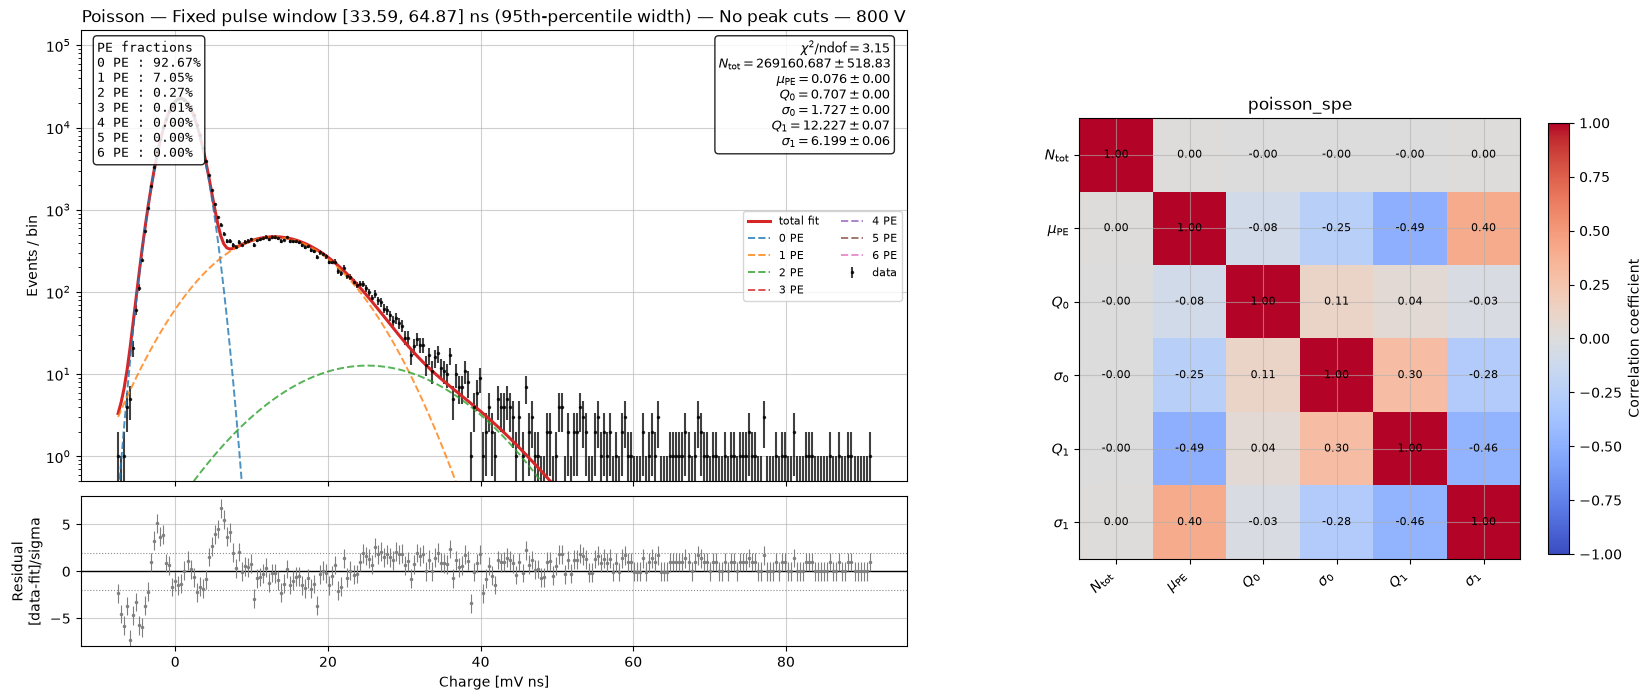

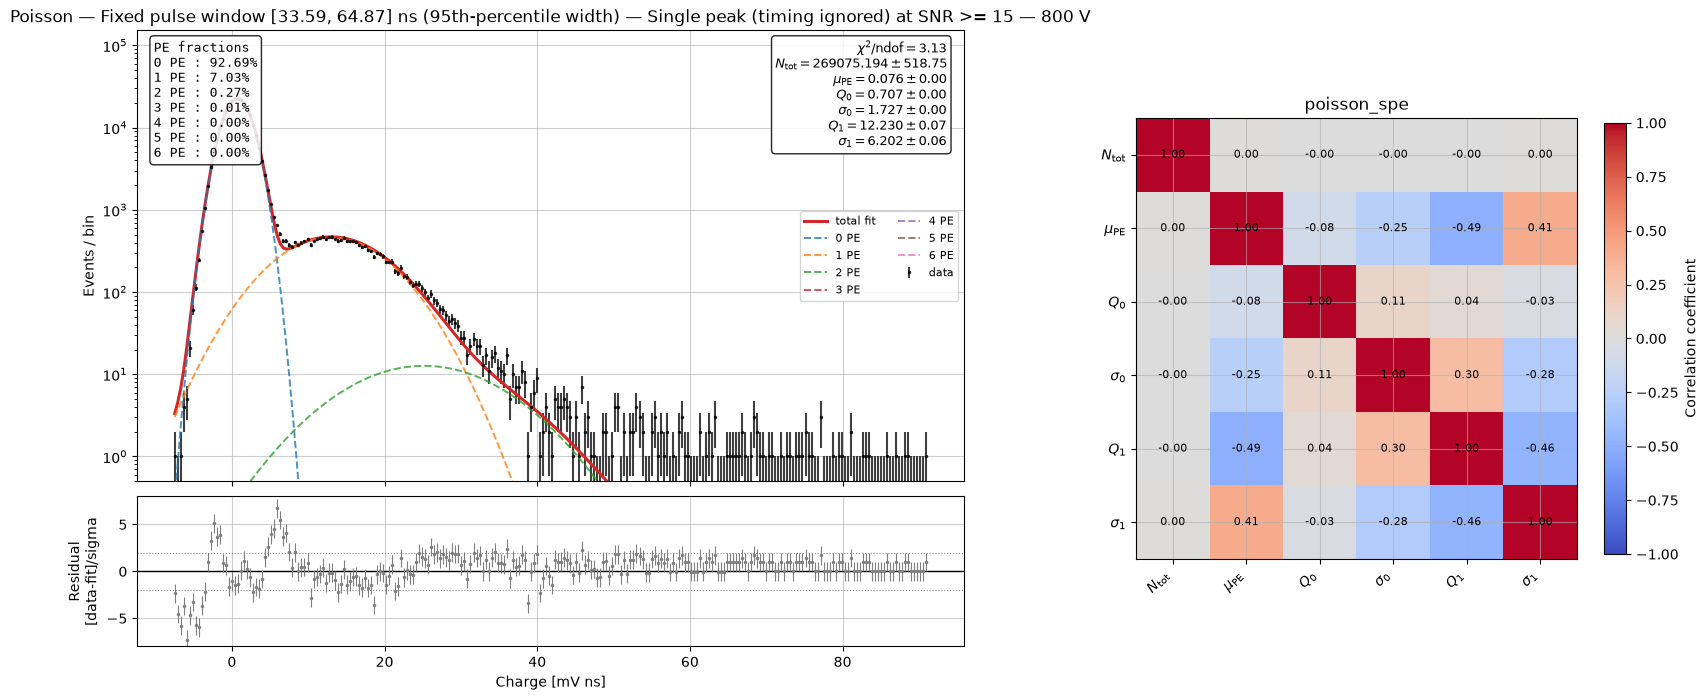

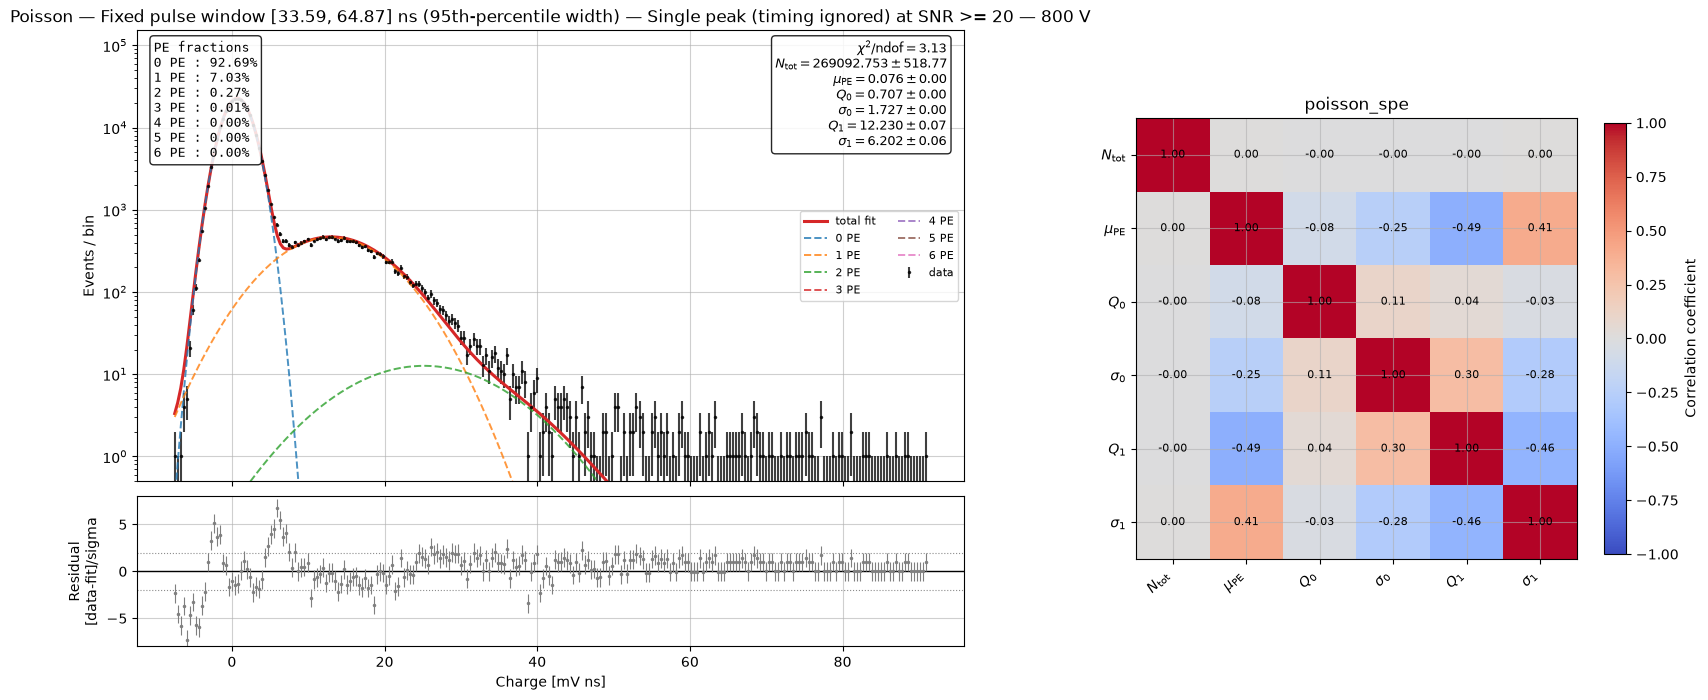

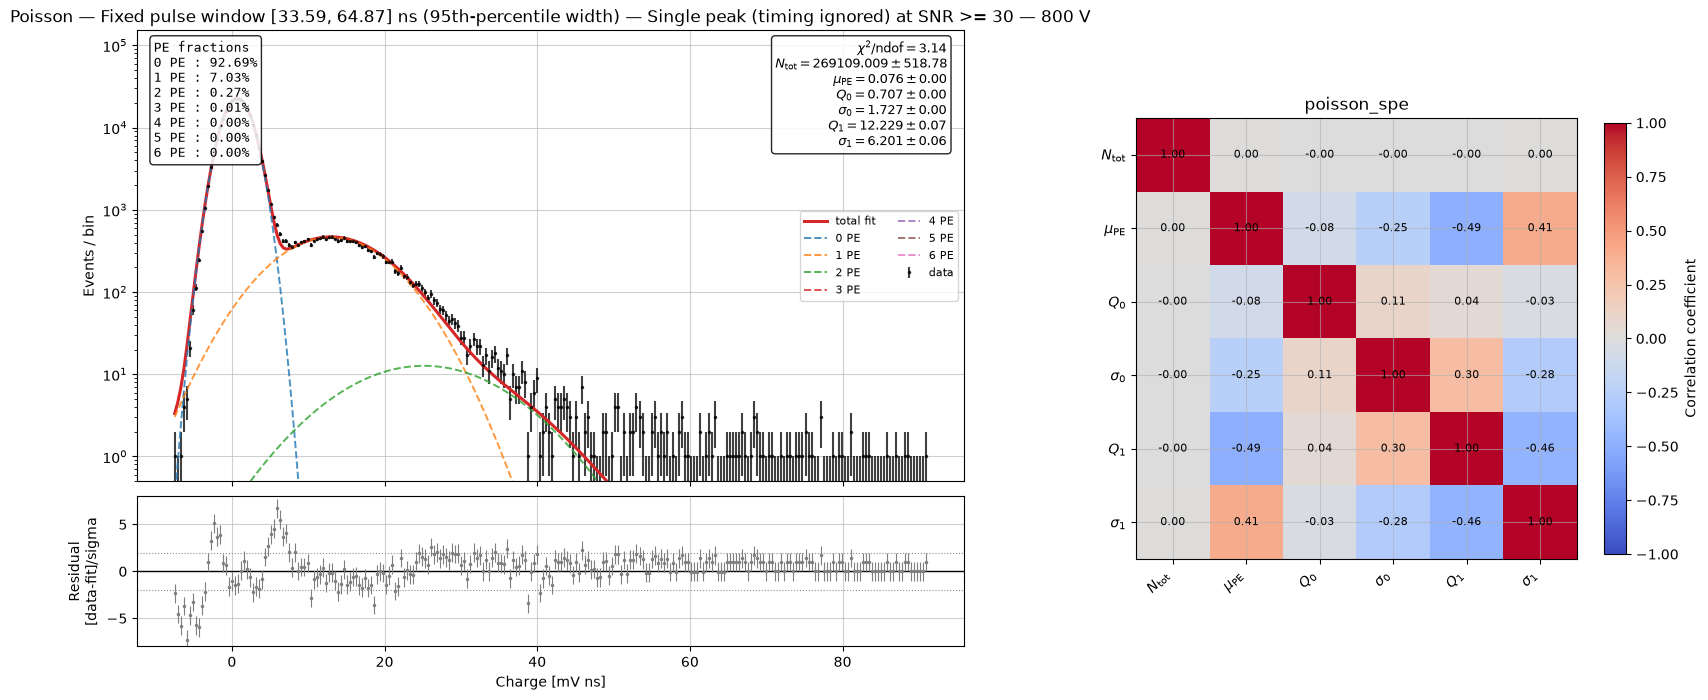

In [26]:
fit_results = {
    method: {config["name"]: {} for config in selection_configs}
    for method in charge_methods
}

if "poisson" in fit_models:
    for method, method_config in charge_methods.items():
        for config in selection_configs:
            name, label = config["name"], config["label"]
            charge_mV_ns = fit_samples[method][name]
            p0 = parameter_specs_for(
                "poisson", method, name, p0_poisson, len(charge_mV_ns)
            )

            print(f"\n===== Poisson: {method_config['label']} - {label} =====")
            result = fit_poisson_spe(
                charge_mV_ns,
                p0=p0,
                max_pe=maxPE,
                bins=nbins,
                fit_range=fit_ranges[method][name],
                maxfev=fit_maxfev,
            )
            fit_results[method][name]["poisson"] = result
            print_fit_result_table(result)
            print(result["diagnostics"])

            title = f"Poisson — {method_config['label']} — {label} — {voltage_V:g} V"
            fig, ax_fit, ax_resid, ax_corr = plot_fit_summary(
                result, title=title, shrink_colorbar=0.7,
                component_visibility_fraction=0, logscale=True,
                show_event_fractions=True, max_fraction_pe=maxPE,
            )
            save_plot(
                fig, save_plots, save_dir, file_nickname,
                f"fit_Poisson_{method}_{name}_{nbins}bins", Nevents=None,
            )
            save_fit_results(
                result,
                output_path=savefit_path / f"{file_nickname}_{method}_{name}_poisson.yaml",
            )
else:
    print("Skipping Poisson fits")


## Bellamy

In [29]:
# Bellamy SPE defaults. Edit initial values, bounds, or fixed flags here.
p0_bellamy = {
    "q0_mV_ns": [1, -6.0, 10.0, False],
    "sigma0_mV_ns": [4, 1e-4, 50.0, False],
    "q1_mV_ns": [14, 0.5, 200.0, False],
    "sigma1_mV_ns": [8, 0.2, 100.0, False],
    "mu_pe": [0.06, 0.001, 5.0, False],
    "w": [0.2, 0.0, 1.0, False],
    "alpha": [0.3, 0.0, 10.0, False],
}



===== Bellamy: Fixed pulse window [33.59, 64.87] ns (95th-percentile width) - No peak cuts =====
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         269908.0000 269478.5168     519.1227   [134954.0, 404862.0]   False
mu_pe                0.0600      0.0527       0.0023             [0.0, 5.0]   False
q0_mV_ns             1.0000      0.6714       0.0044           [-6.0, 10.0]   False
sigma0_mV_ns         4.0000      1.7113       0.0029            [0.0, 50.0]   False
q1_mV_ns            14.0000     13.7346       0.2086           [0.5, 200.0]   False
sigma1_mV_ns         8.0000      5.7497       0.1482           [0.2, 100.0]   False
w                    0.2000      0.0397       0.0030             [0.0, 1.0]   False
alpha                0.3000      0.1619       0.0078            [0.0, 10.0]   False
[]

===== Bellamy: Fixed pulse window [33.59, 64.87] ns (95th-perc

,integration,selection,model,events,fit_range,q0_mV_ns,q1_mV_ns,q1_error_mV_ns,mu_pe,chi2_ndof
0,"Fixed pulse window [33.59, 64.87] ns (95th-per...",No peak cuts,poisson,269908,"(-7.686450351629615, 91.1572279201448)",0.706729,12.227156,0.074481,0.076102,3.147198
1,"Fixed pulse window [33.59, 64.87] ns (95th-per...",No peak cuts,bellamy,269908,"(-7.686450351629615, 91.1572279201448)",0.671393,13.734646,0.208612,0.052653,1.811101
2,"Fixed pulse window [33.59, 64.87] ns (95th-per...",Single peak (timing ignored) at SNR >= 15,poisson,269819,"(-7.686450351629615, 91.1572279201448)",0.706532,12.230339,0.074632,0.075876,3.132724
3,"Fixed pulse window [33.59, 64.87] ns (95th-per...",Single peak (timing ignored) at SNR >= 15,bellamy,269819,"(-7.686450351629615, 91.1572279201448)",0.671220,13.744825,0.209203,0.052426,1.797160
4,"Fixed pulse window [33.59, 64.87] ns (95th-per...",Single peak (timing ignored) at SNR >= 20,poisson,269837,"(-7.686450351629615, 91.1572279201448)",0.706645,12.230114,0.074629,0.075877,3.134511
5,"Fixed pulse window [33.59, 64.87] ns (95th-per...",Single peak (timing ignored) at SNR >= 20,bellamy,269837,"(-7.686450351629615, 91.1572279201448)",0.671330,13.744786,0.209210,0.052423,1.798865
6,"Fixed pulse window [33.59, 64.87] ns (95th-per...",Single peak (timing ignored) at SNR >= 30,poisson,269854,"(-7.686450351629615, 91.1572279201448)",0.706778,12.228588,0.074622,0.075887,3.137610
7,"Fixed pulse window [33.59, 64.87] ns (95th-per...",Single peak (timing ignored) at SNR >= 30,bellamy,269854,"(-7.686450351629615, 91.1572279201448)",0.671419,13.744500,0.209269,0.052413,1.799014


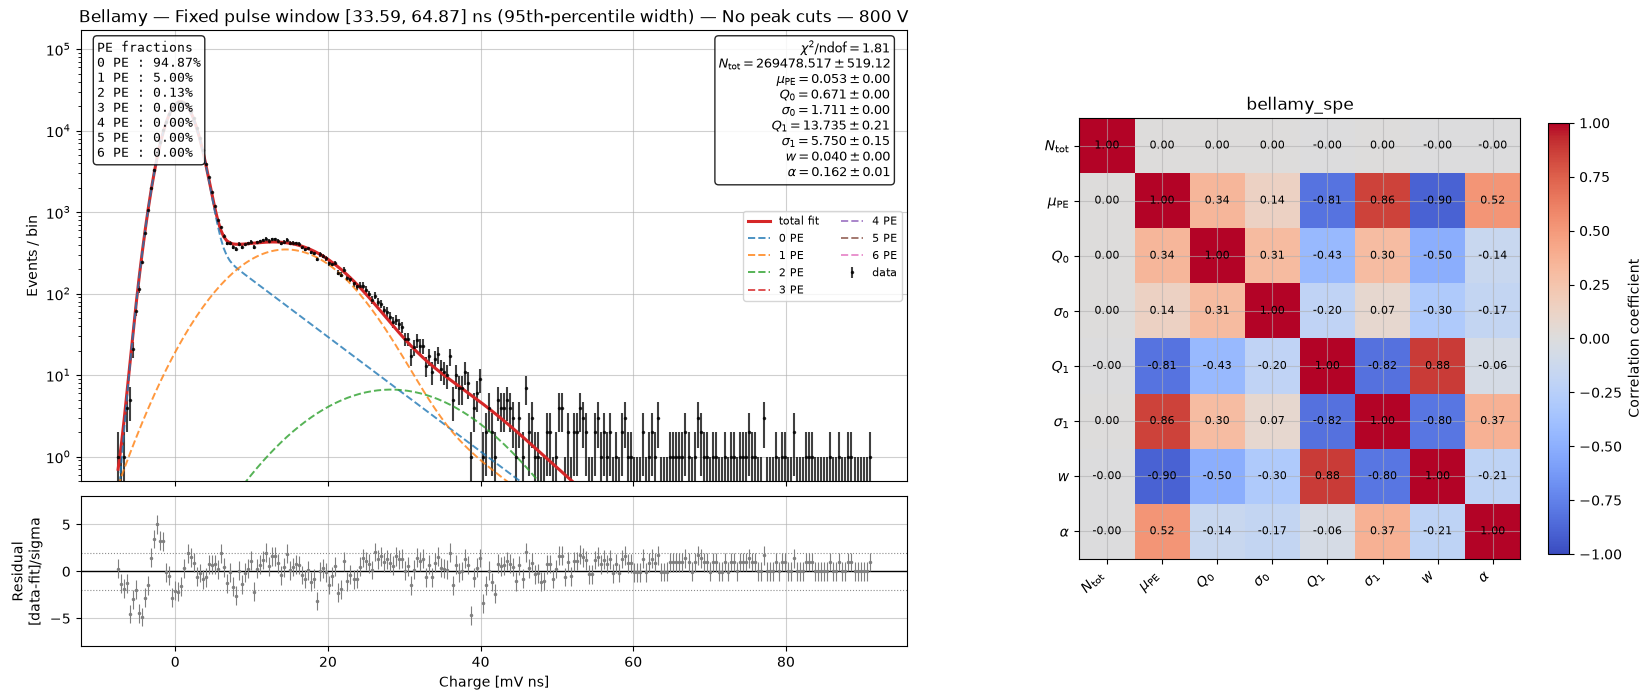

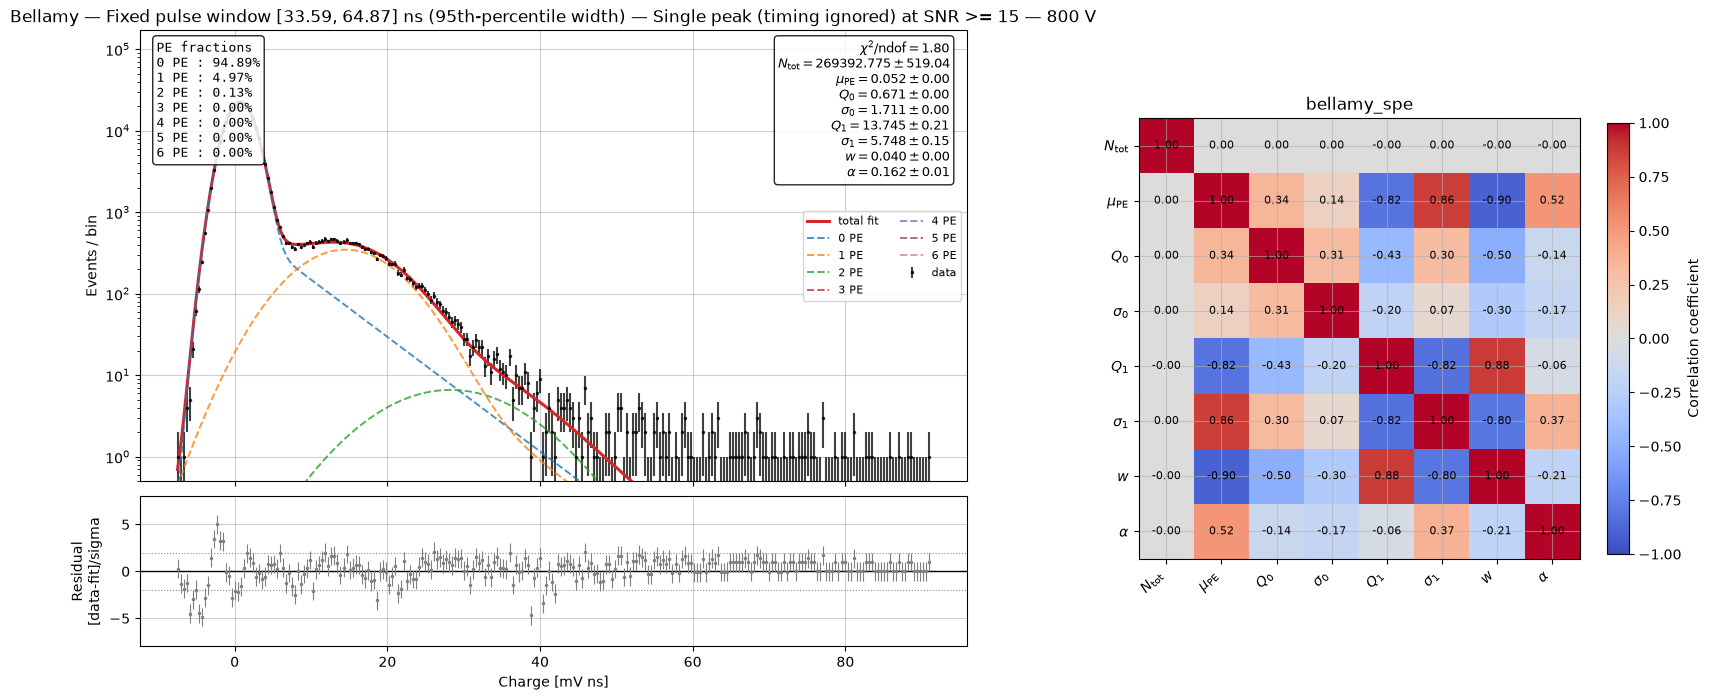

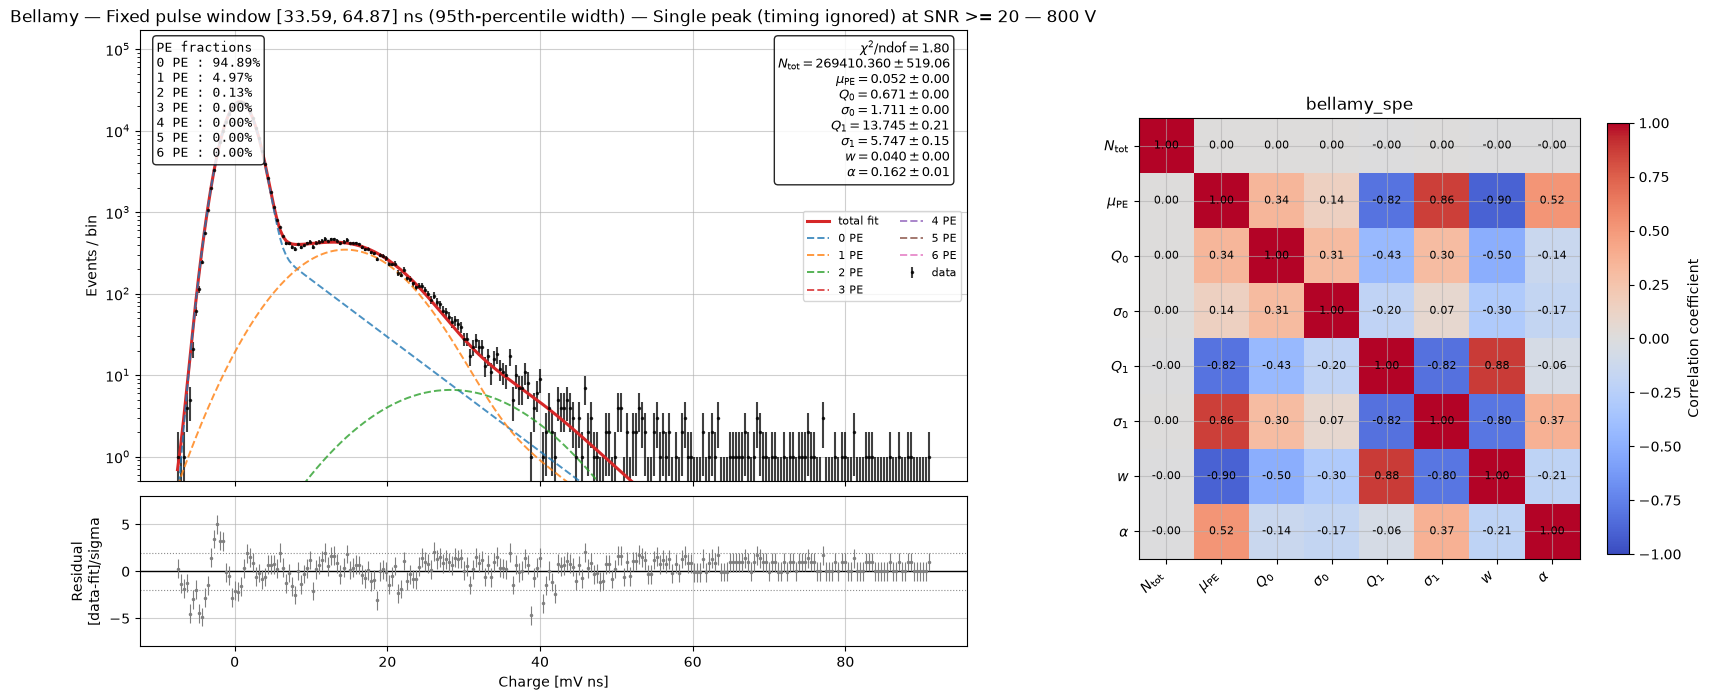

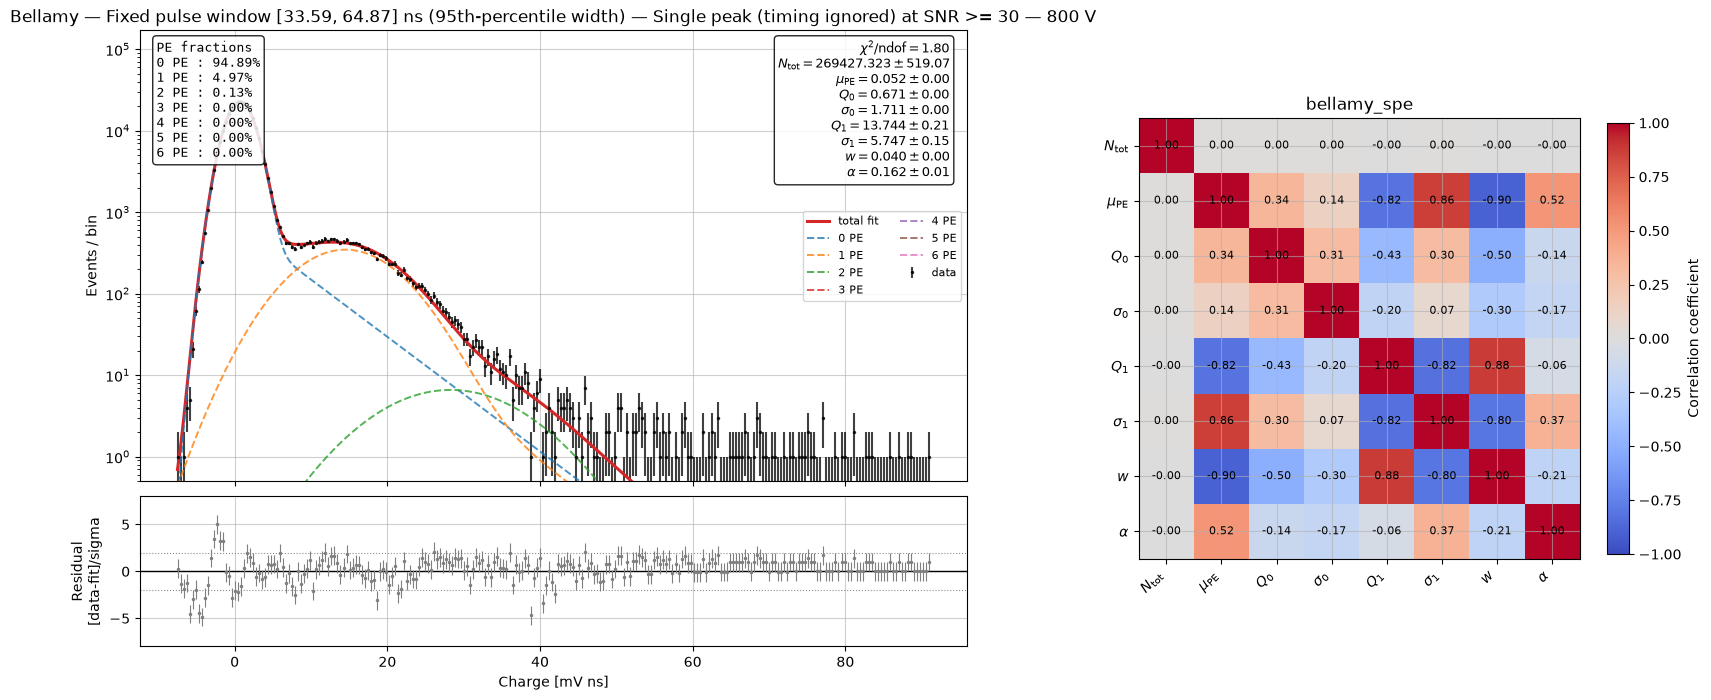

In [30]:
if "bellamy" in fit_models:
    for method, method_config in charge_methods.items():
        for config in selection_configs:
            name, label = config["name"], config["label"]
            charge_mV_ns = fit_samples[method][name]
            p0 = parameter_specs_for(
                "bellamy", method, name, p0_bellamy, len(charge_mV_ns)
            )

            print(f"\n===== Bellamy: {method_config['label']} - {label} =====")
            result = fit_bellamy_spe(
                charge_mV_ns,
                p0=p0,
                max_pe=maxPE,
                bins=nbins,
                fit_range=fit_ranges[method][name],
                maxfev=fit_maxfev,
            )
            fit_results[method][name]["bellamy"] = result
            print_fit_result_table(result)
            print(result["diagnostics"])

            title = f"Bellamy — {method_config['label']} — {label} — {voltage_V:g} V"
            fig, ax_fit, ax_resid, ax_corr = plot_fit_summary(
                result, title=title, shrink_colorbar=0.7,
                component_visibility_fraction=0, logscale=True,
                show_event_fractions=True, max_fraction_pe=maxPE,
            )
            save_plot(
                fig, save_plots, save_dir, file_nickname,
                f"fit_Bellamy_{method}_{name}_{nbins}bins", Nevents=None,
            )
            save_fit_results(
                result,
                output_path=savefit_path / f"{file_nickname}_{method}_{name}_bellamy.yaml",
            )
else:
    print("Skipping Bellamy fits")

# Compact numerical comparison of every completed fit.
comparison_rows = []
for method, method_config in charge_methods.items():
    for config in selection_configs:
        name = config["name"]
        for model, result in fit_results[method][name].items():
            comparison_rows.append({
                "integration": method_config["label"],
                "selection": config["label"],
                "model": model,
                "events": len(fit_samples[method][name]),
                "fit_range": fit_ranges[method][name],
                "q0_mV_ns": result["parameters"].get("q0_mV_ns"),
                "q1_mV_ns": result["parameters"].get("q1_mV_ns"),
                "q1_error_mV_ns": result["errors"].get("q1_mV_ns"),
                "mu_pe": result["parameters"].get("mu_pe"),
                "chi2_ndof": result["chi2"] / result["ndof"] if result["ndof"] else np.nan,
            })

fit_comparison = pd.DataFrame(comparison_rows)
display(fit_comparison)
